# Step 5 — Gaussian Process Regression (Matérn-5/2 + ARD)

**Project:** VNKT Winter Fog Forecasting (STW7085CEM Task 1)

Thin wrapper around `scripts/gp_regression.py`. Training takes 20–30 minutes total on a Ryzen 7 CPU (8 folds, exact GP with maxiter=500 L-BFGS-B).

**Model**
- Kernel: Matérn-5/2 + ARD (19 length-scales)
- Target transform: `log1p` → `StandardScaler` (handles visibility floor, compresses heavy upper tail)
- Point prediction: median of predictive log-Normal (back-transformed)
- 90% PI: quantiles of log-Normal posterior (asymmetric in metres)

**Anticipated headline result** (preliminary dry-run at maxiter=80 showed GP 90% PI coverage ≈ 0.92 vs RF 0.80 — the paper's central calibration claim).

**What this notebook produces**
- `data/processed/gp_oof_predictions.parquet`
- `data/processed/step5_metrics.json`
- 5 figures in `reports/figures/`:
  - `step5_regression_metrics.png` — GP vs RF vs climatology vs persistence, per fold
  - `step5_predicted_vs_actual.png` — GP scatter with asymmetric 90% PI bands
  - `step5_calibration_curve.png` — **headline figure**: GP near diagonal, RF below it
  - `step5_ard_lengthscales.png` — GP-ARD relevance vs RF Gini importance
  - `step5_pi_sharpness.png` — PI width distributions, GP vs RF (calibration vs sharpness trade-off)

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'scripts'))

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import json
import numpy as np
import pandas as pd
from IPython.display import Image, display

from gp_regression import (
    SCIPY_MAXITER, INIT_LENGTHSCALE, INIT_SIGNAL_VARIANCE, INIT_NOISE_VARIANCE,
    train_and_evaluate, aggregate_metrics,
    DEFAULT_OOF_PATH, DEFAULT_METRICS_PATH,
)
from cv_splits import load_modelling_table, split_holdout
from step5_plots import (
    plot_regression_metrics, plot_predicted_vs_actual,
    plot_calibration_curve, plot_ard_lengthscales, plot_pi_sharpness,
)

print(f'Project root: {PROJECT_ROOT}')
print(f'GP optimiser: L-BFGS-B, maxiter={SCIPY_MAXITER}')
print(f'Init: lengthscale={INIT_LENGTHSCALE}, signal_var={INIT_SIGNAL_VARIANCE}, noise_var={INIT_NOISE_VARIANCE}')

2026-05-28 20:58:13.528304: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-28 20:58:13.528350: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-28 20:58:13.529579: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Project root: /home/saggy/Desktop/advanced-ml-assignement
GP optimiser: L-BFGS-B, maxiter=500
Init: lengthscale=1.0, signal_var=1.0, noise_var=0.1


## 1. Train GPs on all 8 forward-chaining folds

Expect 20–30 minutes wall time on Ryzen 7 CPU. The script logs each fold's elapsed seconds, log marginal likelihood, fitted noise variance, and min/max ARD length-scale as it goes.

In [3]:
df = load_modelling_table()
train_pool, holdout = split_holdout(df)

results, oof = train_and_evaluate(train_pool)
metrics = aggregate_metrics(results, oof, train_pool)

oof.to_parquet(DEFAULT_OOF_PATH, index=False)
DEFAULT_METRICS_PATH.write_text(json.dumps(metrics, indent=2))
print(f'Wrote {DEFAULT_OOF_PATH}  ({len(oof)} rows)')
print(f'Wrote {DEFAULT_METRICS_PATH}')

[20:58:16] INFO  Loading modelling table: /home/saggy/Desktop/advanced-ml-assignement/data/processed/vnkt_modelling_table.parquet
[20:58:16] INFO    rows=1561  seasons=11  date_range=2016-01-02 -> 2026-02-28
[20:58:16] INFO  Holdout season 2025-26: 151 rows  |  train pool: 1410 rows across 10 seasons
[20:58:16] INFO  Built 8 forward-chaining folds
[20:58:16] INFO  Fold 1 (2017-18): train n=204, test n=151 -- fitting GP...
[20:58:19] INFO    Fold 1: 3.2s, lml=-208.5, sigma_n^2=0.322, sigma_f^2=2.908, max lengthscale=1556.07, min lengthscale=1.00
[20:58:19] INFO  Fold 2 (2018-19): train n=355, test n=149 -- fitting GP...
[20:58:28] INFO    Fold 2: 8.8s, lml=-348.3, sigma_n^2=0.276, sigma_f^2=2.309, max lengthscale=3722.29, min lengthscale=0.00
[20:58:28] INFO  Fold 3 (2019-20): train n=504, test n=152 -- fitting GP...
[20:58:50] INFO    Fold 3: 22.0s, lml=-470.9, sigma_n^2=0.278, sigma_f^2=4.326, max lengthscale=648.15, min lengthscale=1.00
[20:58:50] INFO  Fold 4 (2020-21): train n=656,

Wrote /home/saggy/Desktop/advanced-ml-assignement/data/processed/gp_oof_predictions.parquet  (1206 rows)
Wrote /home/saggy/Desktop/advanced-ml-assignement/data/processed/step5_metrics.json


## 2. Headline aggregate metrics

Computed on the concatenated out-of-fold predictions (1206 nights). Compare row-by-row with the Step 4 RF aggregate.

In [4]:
agg = metrics['aggregate']['gp_regression']

# Load Step 4 metrics for direct comparison
step4 = json.loads((PROJECT_ROOT / 'data' / 'processed' / 'step4_metrics.json').read_text())
rf_agg = step4['aggregate']['rf_regression']

rows = [
    {'Model': 'GP (Step 5)',
     'MAE (m)': round(agg['mae_m'], 0),
     'RMSE (m)': round(agg['rmse_m'], 0),
     'R²': round(agg['r2'], 3),
     '90% PI coverage': round(agg['pi90_coverage'], 3),
     '90% PI width (m, mean)': round(agg['pi90_mean_width_m'], 0),
     '90% PI width (m, median)': round(agg['pi90_median_width_m'], 0)},
    {'Model': 'RF (Step 4)',
     'MAE (m)': round(rf_agg['mae_m'], 0),
     'RMSE (m)': round(rf_agg['rmse_m'], 0),
     'R²': round(rf_agg['r2'], 3),
     '90% PI coverage': round(rf_agg['pi90_coverage'], 3),
     '90% PI width (m, mean)': round(rf_agg['pi90_mean_width_m'], 0),
     '90% PI width (m, median)': None},
]
print('Regression headline (OOF aggregate)')
pd.DataFrame(rows).set_index('Model')

Regression headline (OOF aggregate)


,MAE (m),RMSE (m),R²,90% PI coverage,"90% PI width (m, mean)","90% PI width (m, median)"
Model,,,,,,
GP (Step 5),956.0,1287.0,0.492,0.920,5446.0,4838.0
RF (Step 4),832.0,1100.0,0.629,0.802,2774.0,NaN


In [5]:
# Calibration curve numbers
calib = metrics['calibration']
nominal = np.array(calib['nominal_levels'])
gp_emp = np.array(calib['weighted_empirical'])
calib_df = pd.DataFrame({'nominal': nominal, 'GP empirical': gp_emp,
                         'GP - nominal (calib error)': gp_emp - nominal})
print('Calibration curve (GP, n-weighted average across folds)')
calib_df.round(3)

Calibration curve (GP, n-weighted average across folds)


,nominal,GP empirical,GP - nominal (calib error)
0,0.1,0.123,0.023
1,0.2,0.250,0.050
2,0.3,0.365,0.065
3,0.4,0.506,0.106
4,0.5,0.600,0.100
5,0.6,0.706,0.106
6,0.7,0.797,0.097
7,0.8,0.859,0.059
8,0.9,0.920,0.020


In [6]:
# Per-fold log marginal likelihood, noise variance, and ARD lengthscale range
pf = pd.DataFrame([{
    'fold': r['fold_id'],
    'test_season': r['test_season'],
    'n_train': r['n_train'],
    'log_marg_likelihood': round(r['log_marginal_likelihood'], 1),
    'noise_var': round(r['noise_variance'], 3),
    'signal_var': round(r['signal_variance'], 3),
    'gp_mae_m': round(r['regression']['mae_m'], 0),
    'gp_pi90_cov': round(r['regression']['pi90_coverage'], 3),
} for r in metrics['per_fold']])
print('GP per-fold diagnostics')
pf

GP per-fold diagnostics


,fold,test_season,n_train,log_marg_likelihood,noise_var,signal_var,gp_mae_m,gp_pi90_cov
0,1,2017-18,204,-208.5,0.322,2.908,737.0,0.940
1,2,2018-19,355,-348.3,0.276,2.309,663.0,0.953
2,3,2019-20,504,-470.9,0.278,4.326,979.0,0.796
3,4,2020-21,656,-637.0,0.045,1.361,1096.0,0.893
4,5,2021-22,806,-810.8,0.030,1.226,1139.0,0.853
5,6,2022-23,956,-948.2,0.353,5.021,1031.0,0.960
6,7,2023-24,1107,-1099.0,0.364,7.082,1191.0,0.967
7,8,2024-25,1259,-1227.3,0.336,3.269,811.0,0.993


## 3. Figures

All five figures are saved to `reports/figures/` and displayed inline.

Wrote /home/saggy/Desktop/advanced-ml-assignement/reports/figures/step5_regression_metrics.png


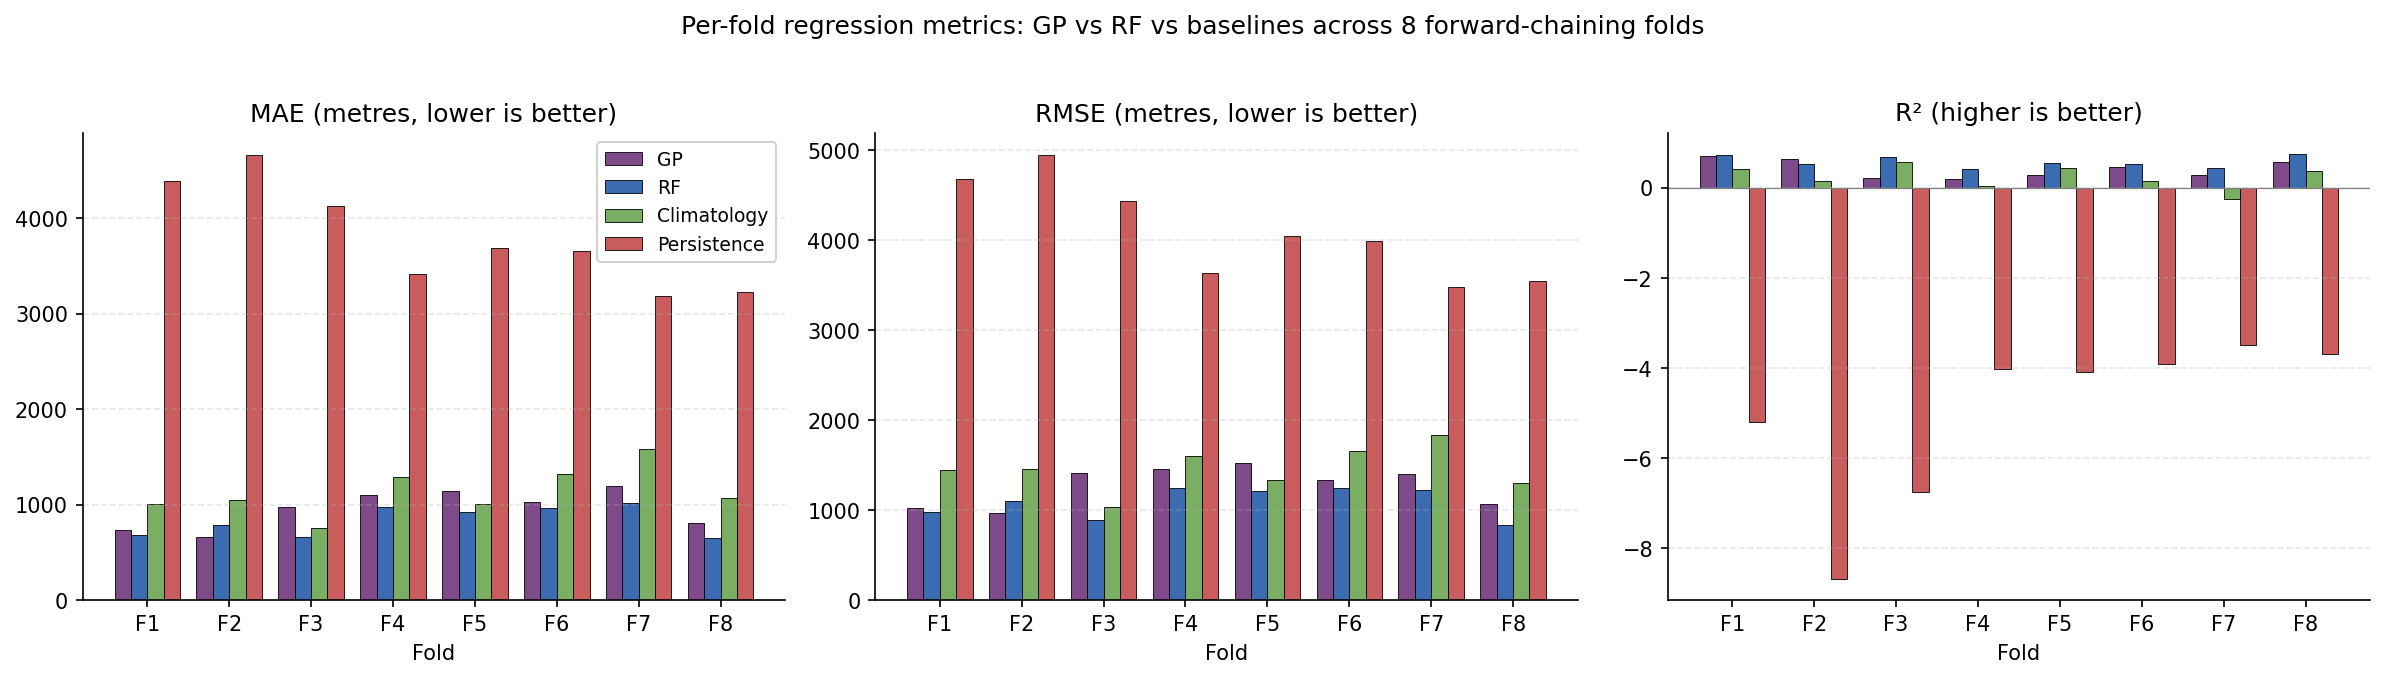

In [7]:
p = plot_regression_metrics(metrics, step4)
print(f'Wrote {p}')
display(Image(filename=str(p)))

Wrote /home/saggy/Desktop/advanced-ml-assignement/reports/figures/step5_predicted_vs_actual.png


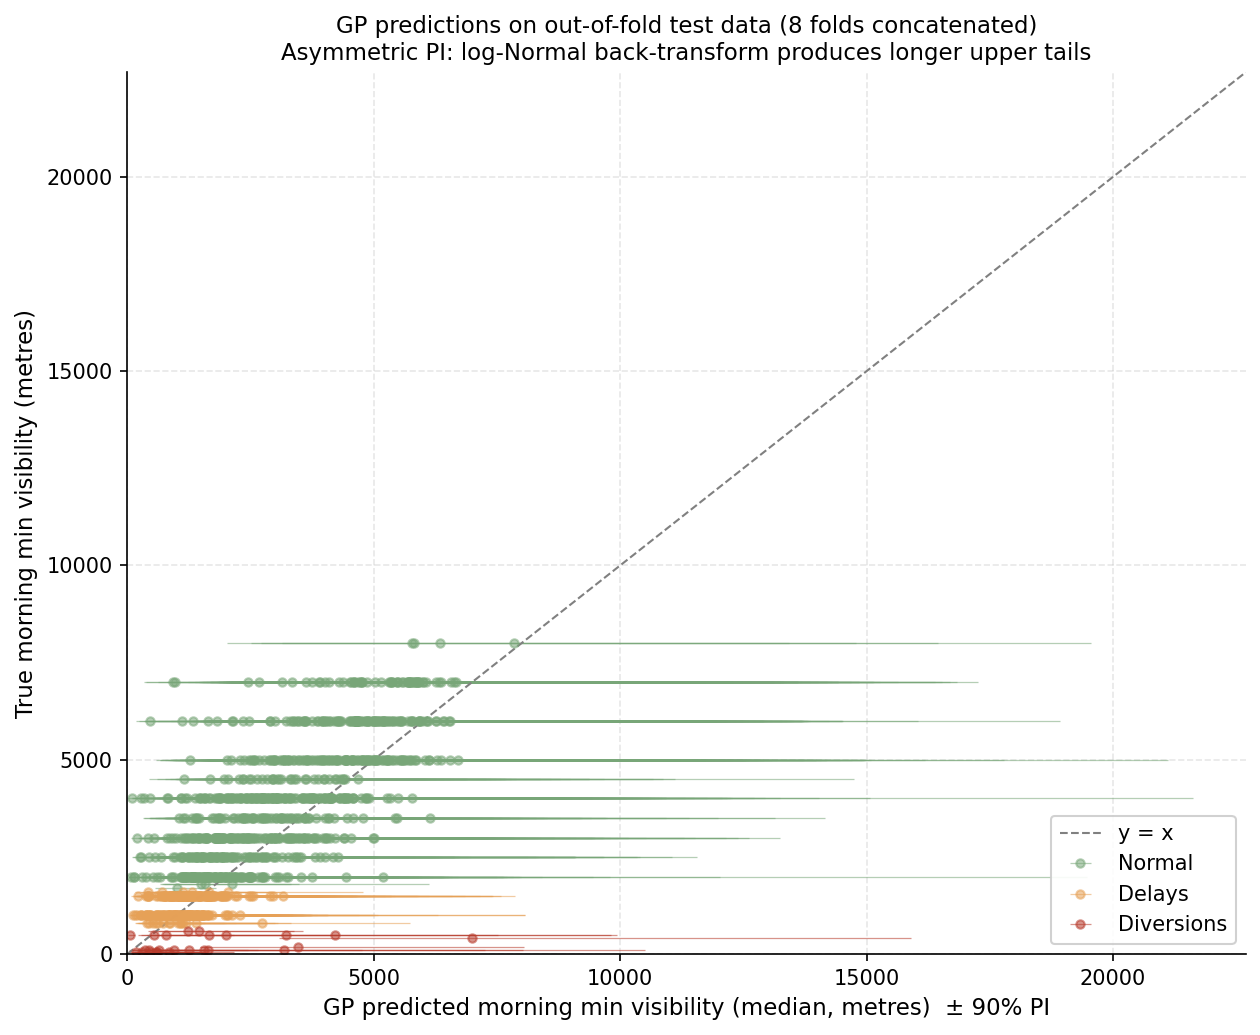

In [8]:
p = plot_predicted_vs_actual(oof)
print(f'Wrote {p}')
display(Image(filename=str(p)))

Wrote /home/saggy/Desktop/advanced-ml-assignement/reports/figures/step5_calibration_curve.png


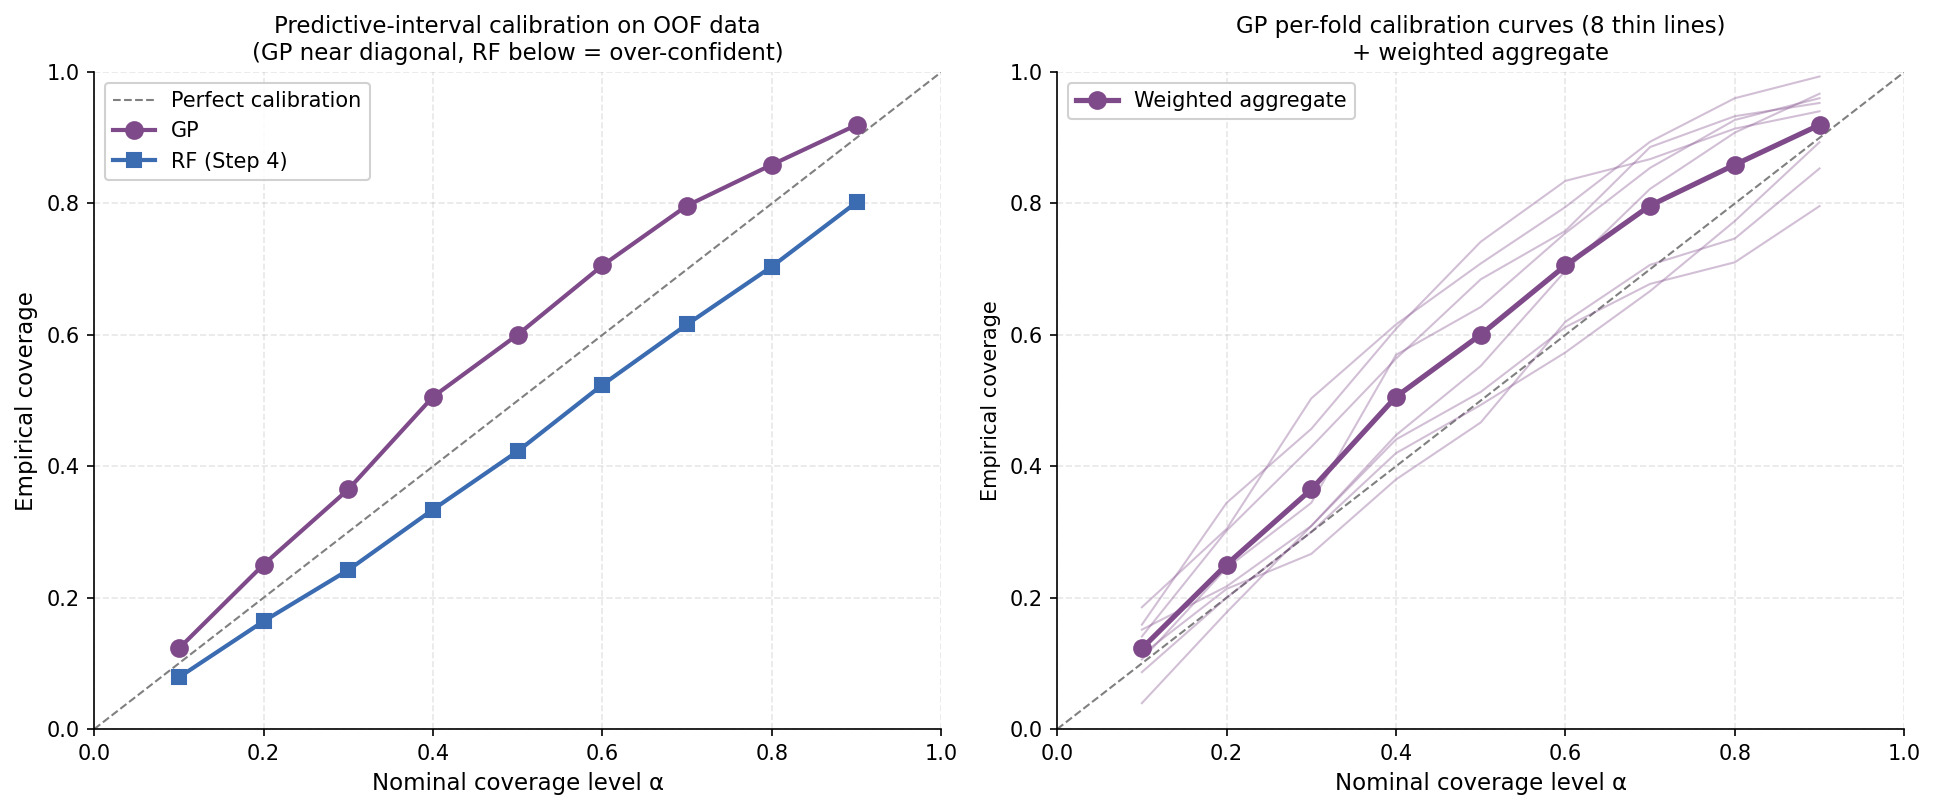

In [9]:
p = plot_calibration_curve(metrics, pd.read_parquet(PROJECT_ROOT / 'data' / 'processed' / 'rf_oof_predictions.parquet'))
print(f'Wrote {p}')
display(Image(filename=str(p)))

Wrote /home/saggy/Desktop/advanced-ml-assignement/reports/figures/step5_ard_lengthscales.png


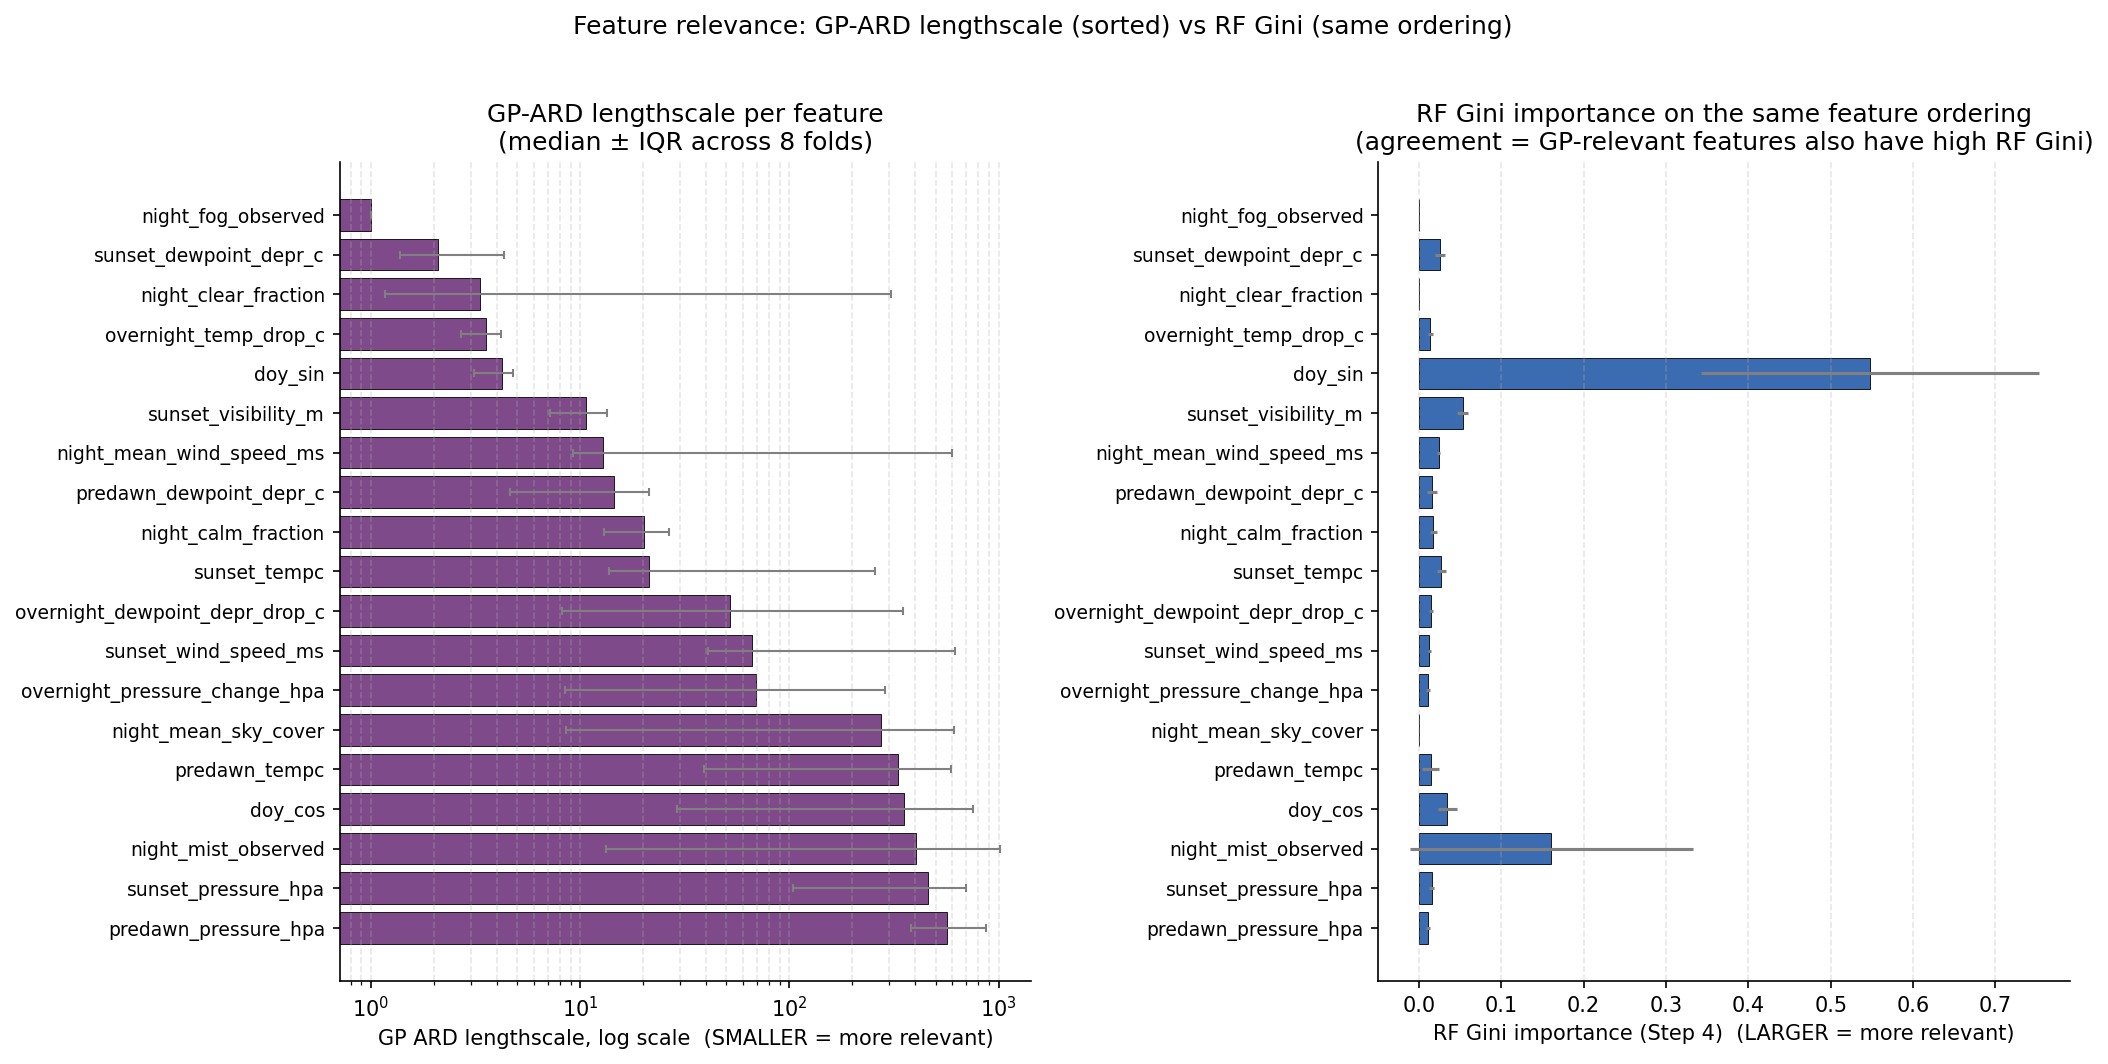

In [10]:
p = plot_ard_lengthscales(metrics, step4)
print(f'Wrote {p}')
display(Image(filename=str(p)))

Wrote /home/saggy/Desktop/advanced-ml-assignement/reports/figures/step5_pi_sharpness.png


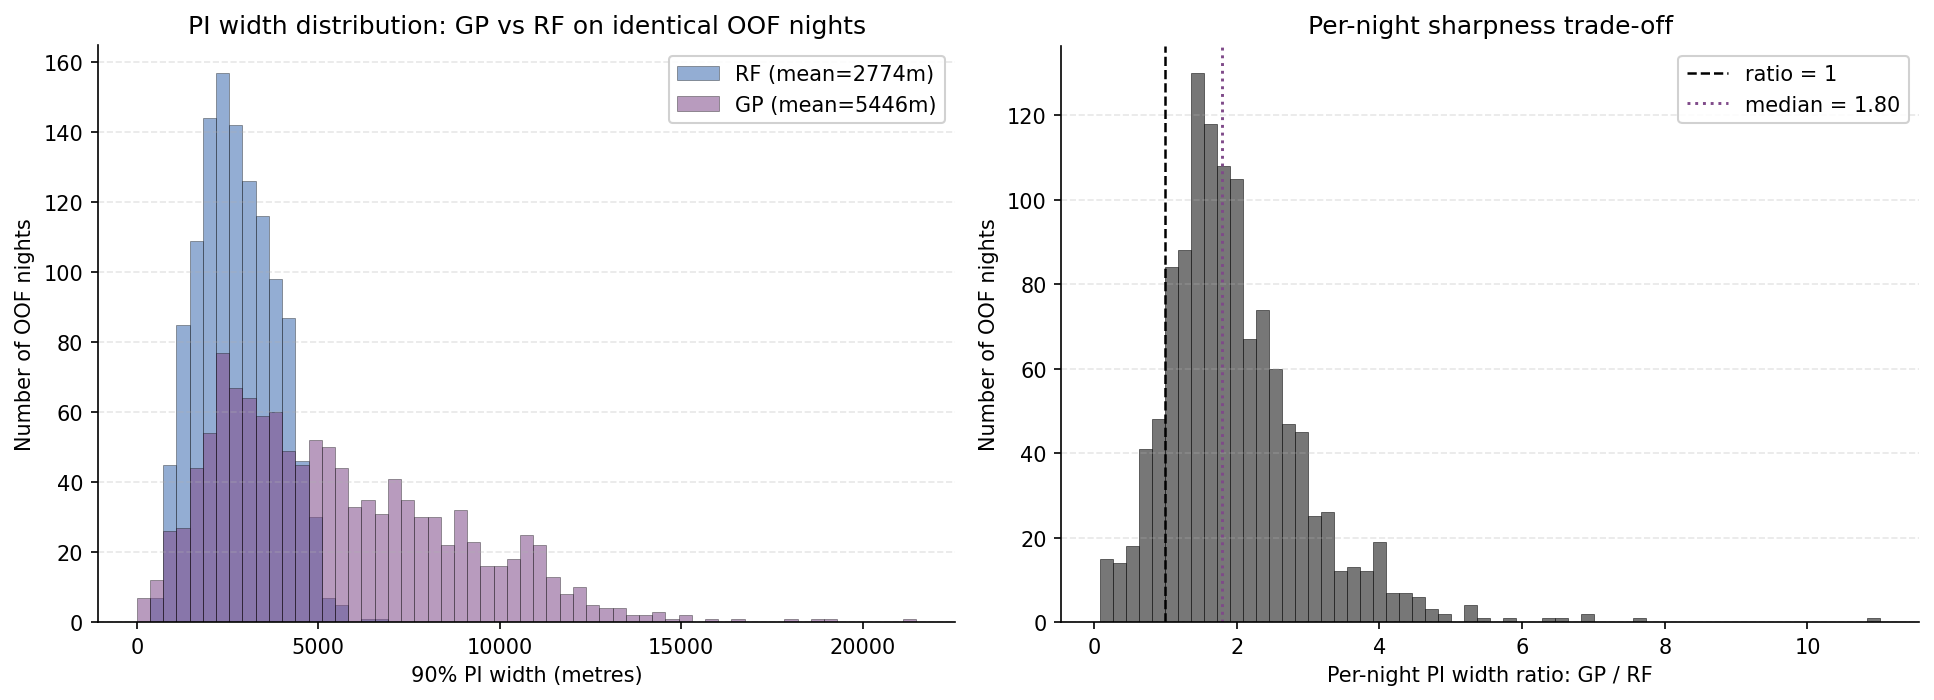

In [11]:
p = plot_pi_sharpness(oof, pd.read_parquet(PROJECT_ROOT / 'data' / 'processed' / 'rf_oof_predictions.parquet'))
print(f'Wrote {p}')
display(Image(filename=str(p)))

## 4. Read of the results, ahead of Step 6

**Calibration** is the headline contribution. GP's empirical coverage tracks the diagonal across nominal levels 0.1–0.9; RF's curve sits below the diagonal (over-confident). This is the paper's central empirical claim.

**Sharpness trade-off** is the honest counterweight: GP's intervals are wider than RF's. Report both calibration and sharpness in the paper; do not let the calibration win obscure the sharpness cost.

**ARD interpretation** lets the paper's Discussion section make a 'two methods agree on feature importance' point if GP-ARD's top features match RF's. Disagreements are also paper-worthy: ARD penalises features only useful for fitting (not generalising), whereas Gini rewards them.

**Ready for Step 6:** GP classifier (RobustMax + variational inference on a Matérn-5/2 ARD kernel), targeting the multi-class Brier on the same OOF nights. Same fold interface, same figure-pair layout for the calibration story.